In [1]:
# REPLACEMENT Cell 1: Robust processing & preprocessing (no leakage, no NaNs)
# - Resamples each subject to a strict 5-minute grid
# - Uses the PyKalman smoothing helper when available
# - Reindexes smoother output to 5-min grid and fills remaining gaps
# - Splits by subject into train/test BEFORE fitting scalers (80/20)
# - Produces per_subject_train, per_subject_test, X_tr_all, y_tr_all, cg_scaler, feat_scaler
# Run this cell in place of the earlier preprocessing cell.

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from datetime import timedelta
import sys, subprocess

# ensure smoothing helper installed (same as before)
subprocess.check_call([sys.executable, "-m", "pip", "install", "git+https://github.com/miriamkw/PyKalmanSmoothingGlucose.git"], stdout=subprocess.DEVNULL)
from smoother.smooth_SMBG_data import smooth_smbg_data

# Parameters (easy to change)
DATA_PATH = "../data/OhioT1DM.csv"
N_IN = 12   # history (12*5 = 60 min)
N_OUT = 6   # horizon (6*5 = 30 min)
RANDOM_STATE = 42
RESAMPLE_RULE = '5T'  # 5 minutes

# Read and sort
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['id','date']).reset_index(drop=True)

# Features to keep (same as before)
feat_cols = ['carbs','bolus','basal','galvanic_skin_response','skin_temp',
             'acceleration','workout_intensity','workout_duration','heartrate','air_temp','steps']
all_features = ['CGM'] + feat_cols

# Helper: robust smoothing + reindexing to regular 5-min grid
def smooth_and_resample_subject(df_sub):
    """
    Input: df_sub sorted by date for a single subject
    Output: df_reg indexed by a strict 5-min grid from min->max with no NaNs in CGM_smoothed or feature columns
    """
    # create full regular index (5-min) spanning subject's time range
    tmin = df_sub['date'].min()
    tmax = df_sub['date'].max()
    # ensure we extend to include endpoints cleanly
    full_idx = pd.date_range(start=tmin.floor('5T'), end=tmax.ceil('5T'), freq=RESAMPLE_RULE)
    # original times and values
    t_orig = df_sub['date'].values
    y_orig = df_sub['CGM'].values.astype(float)

    # Try Kalman smoother on original points (works on irregular timestamps)
    y_smooth_at_out = None
    try:
        res = smooth_smbg_data(t_orig, y_orig, outlier_removal=1, dynamic_model=2)
        # prefer 'y_smoothed_at_tout' if present (smoother evaluated at requested grid)
        y_s = res.get('y_smoothed_at_tout', res.get('y_smoothed', None))
        if y_s is not None:
            # 'y_s' is aligned with the input timestamps by default; we'll map it to timestamps
            # If there's an explicit 'tout' use that; otherwise map to original times
            tout = res.get('tout', None)
            if tout is not None:
                # create series at the smoother's output times -> reindex to 5-min grid
                smooth_series = pd.Series(y_s, index=pd.to_datetime(tout))
            else:
                smooth_series = pd.Series(y_s, index=df_sub['date'].values)
            # reindex to regular grid by interpolation
            smooth_reg = smooth_series.reindex(smooth_series.index.union(full_idx)).sort_index().interpolate(method='time').reindex(full_idx)
            y_smooth_at_out = smooth_reg.values
    except Exception:
        y_smooth_at_out = None

    # Fallback: if Kalman smoothing failed or produced NaNs, do robust pandas interpolation + median filter
    if y_smooth_at_out is None or np.isnan(y_smooth_at_out).all():
        # Build a series of original CGM at original times then reindex and interpolate
        s_orig = pd.Series(y_orig, index=df_sub['date'].values)
        s_reg = s_orig.reindex(s_orig.index.union(full_idx)).sort_index().interpolate(method='time').reindex(full_idx)
        # small rolling median to reduce spikes (window 3)
        s_med = s_reg.rolling(window=3, min_periods=1, center=True).median()
        y_smooth_at_out = s_med.values

    # Now ensure no NaNs remain: interpolation -> forward/back fill -> replace remaining with global median of subject raw CGM
    y_series = pd.Series(y_smooth_at_out, index=full_idx)
    if y_series.isna().any():
        y_series = y_series.interpolate(limit_direction='both')
    if y_series.isna().any():
        y_series = y_series.fillna(method='ffill').fillna(method='bfill')
    if y_series.isna().any():
        # last resort: fill with subject median (should rarely happen)
        subj_med = np.nanmedian(y_orig) if np.isfinite(y_orig).any() else 100.0
        y_series = y_series.fillna(subj_med)

    # For other features: we resample to full grid and forward-fill/backfill
    df_sub_idx = df_sub.set_index('date')
    # keep only the feature columns we care about
    other = df_sub_idx.reindex(df_sub_idx.index.union(full_idx))[feat_cols].sort_index()
    other = other.interpolate(method='time').reindex(full_idx)
    # forward/backfill any remaining NaNs and replace all-NaN columns with zeros if necessary
    other = other.fillna(method='ffill').fillna(method='bfill').fillna(0.0)

    # assemble output dataframe
    out = other.copy()
    out = out.assign(CGM_smoothed = y_series.values)
    out = out.reset_index().rename(columns={'index':'date'})
    # ensure column order
    cols = ['date','CGM_smoothed'] + feat_cols
    out = out[cols]
    return out

# Process all subjects
per_subject = {}
for sid, g in df.groupby('id'):
    g_sorted = g.sort_values('date').reset_index(drop=True)
    per_subject[sid] = smooth_and_resample_subject(g_sorted)

# Ensure no NaNs anywhere in CGM_smoothed across subjects (sanity check)
for sid, df_s in per_subject.items():
    if df_s['CGM_smoothed'].isna().any():
        raise RuntimeError(f"NaNs remain in CGM_smoothed for subject {sid} after smoothing/filling.")

# Split subjects into train/test (80/20) BEFORE fitting scalers to avoid leakage
subject_ids = sorted(list(per_subject.keys()))
train_ids, test_ids = train_test_split(subject_ids, test_size=0.2, random_state=RANDOM_STATE)
print(f"Subjects total: {len(subject_ids)}  train: {len(train_ids)}  test: {len(test_ids)}")

# Fit scalers only on training subjects (no leakage)
all_cgm_train = np.concatenate([per_subject[s]['CGM_smoothed'].values for s in train_ids])
cg_scaler = MinMaxScaler(feature_range=(0,1))
cg_scaler.fit(all_cgm_train.reshape(-1,1))

# Fit feature scaler on training subject rows stacked
all_feats = []
for s in train_ids:
    all_feats.append(per_subject[s][feat_cols].values)
all_feats = np.vstack(all_feats)
feat_scaler = StandardScaler()
feat_scaler.fit(all_feats)

# Sequence creation (same as earlier but robust about empty outputs)
def create_sequences(df_s, n_in=N_IN, n_out=N_OUT):
    """
    produce X (n_samples, n_in, n_features) and y (n_samples, n_out, 1)
    where first channel is scaled CGM and remaining channels are scaled features
    """
    X_list = []
    y_list = []
    cgm = df_s['CGM_smoothed'].values.astype(float)
    other = df_s[feat_cols].values.astype(float)
    # scale
    cgm_s = cg_scaler.transform(cgm.reshape(-1,1)).reshape(-1)
    other_s = feat_scaler.transform(other)
    L = len(df_s)
    for i in range(n_in, L - n_out + 1):
        xin = np.column_stack([cgm_s[i-n_in:i], other_s[i-n_in:i]])  # shape (n_in, 1+len(feat_cols))
        yout = cgm_s[i:i+n_out].reshape(n_out,1)
        X_list.append(xin)
        y_list.append(yout)
    if len(X_list) == 0:
        return np.zeros((0,n_in,1+len(feat_cols))), np.zeros((0,n_out,1))
    X = np.stack(X_list)
    y = np.stack(y_list)
    return X, y

# Build per_subject_train and per_subject_test
per_subject_train = {}
per_subject_test = {}
for sid in train_ids:
    X,y = create_sequences(per_subject[sid])
    per_subject_train[sid] = {'X':X,'y':y}
for sid in test_ids:
    X,y = create_sequences(per_subject[sid])
    per_subject_test[sid] = {'X':X,'y':y}

# Aggregate X_tr_all, y_tr_all (concatenate across train subjects) safely
X_tr_list = [per_subject_train[s]['X'] for s in per_subject_train if per_subject_train[s]['X'].shape[0] > 0]
y_tr_list = [per_subject_train[s]['y'] for s in per_subject_train if per_subject_train[s]['y'].shape[0] > 0]
if len(X_tr_list) > 0:
    X_tr_all = np.concatenate(X_tr_list, axis=0)
    y_tr_all = np.concatenate(y_tr_list, axis=0)
else:
    X_tr_all = np.zeros((0,N_IN,1+len(feat_cols)))
    y_tr_all = np.zeros((0,N_OUT,1))

print("Finished preprocessing.")
print("X_tr_all shape:", X_tr_all.shape, "y_tr_all shape:", y_tr_all.shape)
# These variables are now safe (no NaNs) and ready for training the models.


C:\Users\msbdj\AppData\Local\Temp\ipykernel_9164\1076002460.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=tmin.floor('5T'), end=tmax.ceil('5T'), freq=RESAMPLE_RULE)


Autodetected mg/dL as unit
Smoother flagged measurement 1743 as outlier: t = 10045.0, y = 8.769008769008769 [mmol/L].
Smoother flagged measurement 8689 as outlier: t = 47370.0, y = 6.382506382506382 [mmol/L].
Smoother flagged measurement 14727 as outlier: t = 80995.0, y = 16.87201687201687 [mmol/L].
Smoother flagged measurement 14728 as outlier: t = 81000.0, y = 12.654012654012654 [mmol/L].
Smoother needs a second pass due to outliers detected. Total # outliers in input data: 4


C:\Users\msbdj\AppData\Local\Temp\ipykernel_9164\1076002460.py:99: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  other = other.fillna(method='ffill').fillna(method='bfill').fillna(0.0)
C:\Users\msbdj\AppData\Local\Temp\ipykernel_9164\1076002460.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=tmin.floor('5T'), end=tmax.ceil('5T'), freq=RESAMPLE_RULE)


Autodetected mg/dL as unit
Smoother flagged measurement 975 as outlier: t = 5055.0, y = 4.828504828504828 [mmol/L].
Smoother flagged measurement 1563 as outlier: t = 7995.0, y = 15.54001554001554 [mmol/L].
Smoother flagged measurement 1564 as outlier: t = 8000.0, y = 14.263514263514264 [mmol/L].
Smoother flagged measurement 1566 as outlier: t = 8010.0, y = 9.268509268509268 [mmol/L].
Smoother flagged measurement 1574 as outlier: t = 8050.0, y = 13.32001332001332 [mmol/L].
Smoother flagged measurement 1575 as outlier: t = 8055.0, y = 12.543012543012543 [mmol/L].
Smoother flagged measurement 1577 as outlier: t = 8065.0, y = 8.935508935508935 [mmol/L].
Smoother flagged measurement 1608 as outlier: t = 8220.0, y = 9.213009213009213 [mmol/L].
Smoother flagged measurement 1610 as outlier: t = 8230.0, y = 6.715506715506716 [mmol/L].
Smoother flagged measurement 1615 as outlier: t = 8255.0, y = 9.046509046509046 [mmol/L].
Smoother flagged measurement 1617 as outlier: t = 8265.0, y = 5.99400599

C:\Users\msbdj\AppData\Local\Temp\ipykernel_9164\1076002460.py:99: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  other = other.fillna(method='ffill').fillna(method='bfill').fillna(0.0)
C:\Users\msbdj\AppData\Local\Temp\ipykernel_9164\1076002460.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=tmin.floor('5T'), end=tmax.ceil('5T'), freq=RESAMPLE_RULE)


...

Autodetected mg/dL as unit
Smoother flagged measurement 267 as outlier: t = 2360.0, y = 16.206016206016205 [mmol/L].
Smoother flagged measurement 4922 as outlier: t = 26710.0, y = 9.879009879009878 [mmol/L].
Smoother flagged measurement 7918 as outlier: t = 46800.0, y = 5.328005328005328 [mmol/L].
Smoother flagged measurement 7997 as outlier: t = 47445.0, y = 5.55000555000555 [mmol/L].
Smoother flagged measurement 8020 as outlier: t = 47565.0, y = 9.324009324009324 [mmol/L].
Smoother flagged measurement 8183 as outlier: t = 48895.0, y = 7.548007548007548 [mmol/L].
Smoother flagged measurement 8878 as outlier: t = 54555.0, y = 11.71051171051171 [mmol/L].
Smoother flagged measurement 9048 as outlier: t = 55425.0, y = 8.935508935508935 [mmol/L].
Smoother flagged measurement 9052 as outlier: t = 55445.0, y = 6.271506271506271 [mmol/L].
Smoother flagged measurement 9054 as outlier: t = 55455.0, y = 8.824508824508824 [mmol/L].
Smoother flagged measurement 9055 as outlier: t = 55460.0, y = 8.

C:\Users\msbdj\AppData\Local\Temp\ipykernel_9164\1076002460.py:99: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  other = other.fillna(method='ffill').fillna(method='bfill').fillna(0.0)
C:\Users\msbdj\AppData\Local\Temp\ipykernel_9164\1076002460.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=tmin.floor('5T'), end=tmax.ceil('5T'), freq=RESAMPLE_RULE)


Autodetected mg/dL as unit
Smoother flagged measurement 624 as outlier: t = 8070.0, y = 3.4410034410034407 [mmol/L].
Smoother flagged measurement 625 as outlier: t = 8075.0, y = 6.271506271506271 [mmol/L].
Smoother flagged measurement 779 as outlier: t = 9595.0, y = 7.104007104007104 [mmol/L].
Smoother flagged measurement 1734 as outlier: t = 14395.0, y = 13.264513264513264 [mmol/L].
Smoother flagged measurement 2199 as outlier: t = 19905.0, y = 6.438006438006438 [mmol/L].
Smoother flagged measurement 2200 as outlier: t = 19910.0, y = 9.37950937950938 [mmol/L].
Smoother flagged measurement 2367 as outlier: t = 20930.0, y = 10.71151071151071 [mmol/L].
Smoother flagged measurement 2508 as outlier: t = 21635.0, y = 10.989010989010989 [mmol/L].
Smoother flagged measurement 2730 as outlier: t = 22750.0, y = 5.772005772005771 [mmol/L].
Smoother flagged measurement 3916 as outlier: t = 29285.0, y = 5.772005772005771 [mmol/L].
Smoother flagged measurement 5538 as outlier: t = 38705.0, y = 7.10

C:\Users\msbdj\AppData\Local\Temp\ipykernel_9164\1076002460.py:99: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  other = other.fillna(method='ffill').fillna(method='bfill').fillna(0.0)


Subjects total: 12  train: 9  test: 3
Finished preprocessing.
X_tr_all shape: (142531, 12, 12) y_tr_all shape: (142531, 6, 1)


In [ ]:
# ============================
# EVALUATION — ONLY PINN MODEL
# ============================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from collections import Counter
import math
from scipy.signal import correlate

# (All helper functions remain identical to your long evaluation block)
# --- copy/paste the entire block EXACTLY as you provided ---
# BUT remove references to persistence, bergman, lstm, ml_corrector

models = {
    'pinn': pinn_model['predict']
}

# (Then the rest of your long evaluation cell remains unchanged,
# simply using the "models" dict above)

# ... paste full evaluation cell here ...

# --------------------------
# Helpers (scaler inversion, glycemia classes, metrics)
# --------------------------
def inv_cgm_with_cg_scaler(y_scaled):
    """y_scaled: array shape (..., N_OUT) or (..., N_OUT, 1) -> returns same shape in mg/dL"""
    if y_scaled is None or np.asarray(y_scaled).size == 0:
        return np.array([]).reshape(0, N_OUT)
    arr = np.asarray(y_scaled)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr.reshape(arr.shape[0], arr.shape[1])
    flat = arr.reshape(-1, 1)
    inv = cg_scaler.inverse_transform(flat).reshape(-1, N_OUT)
    return inv

HYPO = 70.0; HYPER = 180.0
def glycemia_class(x):
    x = np.asarray(x).reshape(-1)
    cls = np.full(x.shape, -1, dtype=int)
    cls[x < HYPO] = 0
    cls[(x >= HYPO) & (x <= HYPER)] = 1
    cls[x > HYPER] = 2
    return cls

# ---------- Updated Temporal Gain (TG) implementation ----------
def temporal_gain(y_true, y_pred, prediction_horizon):
    """
    Compute Temporal Gain (TG) following the description:
      - For each forecast window (length = horizon steps), compute cross-correlation between measured
        and predicted horizon-length vectors.
      - Restrict allowed delay tau to [0 .. max_lag_steps] where max_lag_steps = prediction_horizon / dt.
      - Find tau that maximizes abs(cross_corr). Convert tau to minutes: tau_minutes = tau * dt.
      - TG_window = prediction_horizon - tau_minutes.
      - Aggregate windows by median and return TG (minutes), clipped to [0, prediction_horizon].
    Inputs:
      y_true: array shape (n_windows, horizon) OR (n_windows*horizon,) that can be reshaped
      y_pred: same shape as y_true
      prediction_horizon: minutes (e.g., 30)
    Returns:
      median_TG_minutes (int)
    Notes:
      - If a window has very low variance (constant), it is considered uninformative and TG_window = 0.
      - This implementation follows the paper's definition TG = PH - delay * dt.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # infer horizon in steps and dt in minutes
    # prefer global N_OUT if available
    if 'N_OUT' in globals():
        horizon = int(N_OUT)
    else:
        # fallback: assume dt = 5 and compute horizon
        horizon = int(prediction_horizon // 5) or 1
    dt_minutes = float(prediction_horizon) / float(horizon)  # e.g., 30/6 = 5

    # reshape if flattened inputs were provided
    if y_true.ndim == 1 and y_pred.ndim == 1 and (y_true.size % horizon == 0) and (y_pred.size % horizon == 0):
        try:
            y_true = y_true.reshape(-1, horizon)
            y_pred = y_pred.reshape(-1, horizon)
        except Exception:
            return int(prediction_horizon)

    # check shapes
    if y_true.ndim != 2 or y_pred.ndim != 2 or y_true.shape[1] != y_pred.shape[1]:
        # cannot compute TG meaningfully
        return int(prediction_horizon)

    n_windows, L = y_true.shape
    max_lag_steps = int(prediction_horizon // dt_minutes)  # should equal horizon typically
    # ensure integer bounds
    max_lag_steps = min(max_lag_steps, L - 1)

    tg_windows = []
    for i in range(n_windows):
        t = y_true[i].astype(float)
        p = y_pred[i].astype(float)

        # Skip windows with NaNs entirely
        if np.all(np.isnan(t)) or np.all(np.isnan(p)):
            tg_windows.append(0)
            continue

        # If true or predicted horizon is (nearly) constant: uninformative for cross-correlation
        if np.nanstd(t) < 1e-8 or np.nanstd(p) < 1e-8:
            # treat as no timing information -> TG = 0 (as per your preference; persistence thus gets 0)
            tg_windows.append(0)
            continue

        # center signals
        t0 = t - np.nanmean(t)
        p0 = p - np.nanmean(p)

        # full cross-correlation and lags: -(L-1) .. (L-1)
        cc = correlate(t0, p0, mode='full')
        full_lags = np.arange(-L + 1, L)

        # allow only non-negative delays up to max_lag_steps
        valid_mask = (full_lags >= 0) & (full_lags <= max_lag_steps)
        valid_lags = full_lags[valid_mask]
        valid_cc   = cc[valid_mask]

        if valid_cc.size == 0:
            # no valid cross-correlation region -> worst-case
            tg_windows.append(0)
            continue

        # find delay (in steps) that maximizes abs(cross-corr)
        idx = np.argmax(np.abs(valid_cc))
        delay_steps = int(valid_lags[idx])
        delay_minutes = delay_steps * dt_minutes
        tg_val = prediction_horizon - delay_minutes
        # clip to [0, prediction_horizon]
        tg_val = max(0.0, min(float(prediction_horizon), float(tg_val)))
        tg_windows.append(tg_val)

    if len(tg_windows) == 0:
        return int(prediction_horizon)
    # aggregate by median for robustness
    tg_median = float(np.median(tg_windows))
    return int(round(tg_median))

# --- other metrics unchanged ---
def g_mean(y_true, y_pred):
    from sklearn.metrics import recall_score
    t = glycemia_class(y_true); p = glycemia_class(y_pred)
    recalls = recall_score(t, p, average=None, zero_division=0)
    recalls = np.where(recalls == 0, 1e-10, recalls)
    return float(np.exp(np.mean(np.log(recalls))))

def glucose_weighted_rmse(y_true, y_pred):
    y_true = np.asarray(y_true).flatten(); y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    w = np.maximum(y_true, 0.0)
    if w.sum() == 0:
        w = np.ones_like(w)
    w = w / w.sum()
    return math.sqrt(np.sum(w * (y_true - y_pred)**2))

def glucose_weighted_mae(y_true, y_pred):
    y_true = np.asarray(y_true).flatten(); y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    w = np.maximum(y_true, 0.0)
    if w.sum() == 0:
        w = np.ones_like(w)
    w = w / w.sum()
    return np.sum(w * np.abs(y_true - y_pred))

# Clarke/Parkes fallback (fast)
def clarke_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred): return None
    if (ref >= 70 and abs(pred - ref) <= 0.2 * ref) or (ref < 70 and abs(pred - ref) <= 20): return 'A'
    if (pred >= 330 and ref <= 50) or (pred <= 50 and ref >= 330): return 'E'
    if ref < 70 and pred >= 180: return 'C'
    if ref >= 180 and pred < 70: return 'D'
    return 'B'
def parkes_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred): return None
    err = pred - ref; rel_err = abs(err) / max(ref,1.0)
    if (ref < 70 and abs(err) <= 15) or (ref >= 70 and rel_err <= 0.2): return 'A'
    if rel_err <= 0.35: return 'B'
    if (ref < 70 and pred > 180) or (ref > 180 and pred < 70): return 'D'
    if rel_err > 0.6: return 'E'
    return 'C'

# --------------------------
# Prepare batched predictions for each model across all test subjects
# (unchanged from previously working code)
# --------------------------

#def ml_corrector_predict_fast(sid):
    info = per_subject_test.get(sid, None)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    Xs = info['X']
    resid_scaled = model_corr.predict(Xs, batch_size=128)
    subj = per_subject[sid]
    n_windows = Xs.shape[0]
    G_inits = subj['CGM_smoothed'].values[N_IN-1 : N_IN-1 + n_windows]
    bolus_mat = np.zeros((n_windows, N_OUT))
    carbs_mat  = np.zeros((n_windows, N_OUT))
    for w in range(n_windows):
        start = N_IN + w
        bolus_mat[w, :] = subj['bolus'].values[start:start+N_OUT]
        carbs_mat[w, :] = subj['carbs'].values[start:start+N_OUT]
    p1, p2, p3, k_i, Gb = bergman_model['params']
    dt_scale = (5.0 / 5.0)
    berg_preds = np.zeros((n_windows, N_OUT))
    G = G_inits.copy().astype(float)
    I = np.zeros(n_windows)
    for t in range(N_OUT):
        I = I * math.exp(-k_i) + bolus_mat[:, t]
        meal_effect = p3 * carbs_mat[:, t]
        dG = -p1 * (G - Gb) - p2 * I + meal_effect
        G = G + dG * dt_scale
        berg_preds[:, t] = G
    berg_preds_scaled = cg_scaler.transform(berg_preds.reshape(-1,1)).reshape(-1, N_OUT)
    corrected_scaled = berg_preds_scaled + resid_scaled
    return corrected_scaled.reshape(n_windows, N_OUT, 1)

# --------------------------
# Build arrays across ALL test windows for each model (batched per subject)
# --------------------------
all_results = {}
for mname, mpredict in models.items():
    Ys = []
    for sid, info in per_subject_test.items():
        X_test = info['X']
        if X_test.shape[0] == 0:
            continue
        yhat_scaled = mpredict(sid)
        yhat_scaled = np.asarray(yhat_scaled)
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        yhat_mg = inv_cgm_with_cg_scaler(yhat_scaled)
        Ys.append(yhat_mg)
    all_results[mname] = np.vstack(Ys) if len(Ys) else np.zeros((0, N_OUT))

# Build ground-truth (all windows)
y_true_all_windows = []
for sid, info in per_subject_test.items():
    y_test = info['y']
    if y_test.shape[0] == 0:
        continue
    y_true_mg = inv_cgm_with_cg_scaler(y_test.reshape(-1, N_OUT))
    y_true_all_windows.append(y_true_mg)
if len(y_true_all_windows) == 0:
    raise RuntimeError("No test windows found.")
y_true_all = np.vstack(y_true_all_windows)

# --------------------------
# Metrics (per-horizon and final-step)
# --------------------------
horiz_steps = np.arange(1, N_OUT+1) * 5
print("\n=== Per-horizon RMSE / MAE for each model ===")
per_horizon = {}
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        print(f"Model {mname}: no predictions")
        continue
    rmse_h = []
    mae_h = []
    for h in range(N_OUT):
        y_t = y_true_all[:, h]
        y_p = ypred_all[:, h]
        rmse_h.append(np.sqrt(mean_squared_error(y_t, y_p)))
        mae_h.append(mean_absolute_error(y_t, y_p))
    per_horizon[mname] = {'rmse': rmse_h, 'mae': mae_h}
    print(f"\nModel: {mname}")
    print("Horizon (min):", list(horiz_steps))
    print("RMSE (mg/dL): ", [round(v,2) for v in rmse_h])
    print("MAE  (mg/dL): ", [round(v,2) for v in mae_h])

print("\n=== Final-step aggregated metrics (30 min) ===")
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    ref = y_true_all[:, -1]; pred = ypred_all[:, -1]
    rmse_val = np.sqrt(mean_squared_error(ref, pred))
    mae_val  = mean_absolute_error(ref, pred)
    gw_rmse = glucose_weighted_rmse(ref, pred)
    gw_mae  = glucose_weighted_mae(ref, pred)
    # compute TG using multi-step arrays and the paper definition TG = PH - delay*dt (median across windows)
    tg = temporal_gain(y_true_all, ypred_all, prediction_horizon=5*N_OUT)
    gm = g_mean(ref, pred)
    print(f"\nModel: {mname}")
    print(f"  windows: {len(ref)}")
    print(f"  RMSE: {rmse_val:.3f}  MAE: {mae_val:.3f}")
    print(f"  Glucose-weighted RMSE: {gw_rmse:.3f}  Glucose-weighted MAE: {gw_mae:.3f}")
    print(f"  Temporal gain (min): {tg}   G-Mean: {gm:.4f}")

# --------------------------
# Clarke & Parkes (fallback) + scatter plots per model (final step)
# --------------------------
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    ref = y_true_all[:, -1]; pred = ypred_all[:, -1]
    cz = [clarke_zone_for_point(r,p) for r,p in zip(ref, pred)]
    pz = [parkes_zone_for_point(r,p) for r,p in zip(ref, pred)]
    c_counts = dict(Counter(cz)); p_counts = dict(Counter(pz)); total = len(ref)
    print(f"\n{mname} Clarke zones: ", {k:(c_counts[k], round(100*c_counts[k]/total,2)) for k in c_counts})
    print(f"{mname} Parkes zones : ", {k:(p_counts[k], round(100*p_counts[k]/total,2)) for k in p_counts})

    fig, ax = plt.subplots(1,2, figsize=(12,5))
    ax0 = ax[0]
    ax0.scatter(ref, pred, s=6, alpha=0.5)
    ax0.plot([0,400],[0,400],'--', linewidth=0.8)
    xs = np.linspace(0,400,100); ax0.plot(xs, 1.2*xs, linewidth=0.6); ax0.plot(xs, 0.8*xs, linewidth=0.6)
    ax0.axvline(70, linestyle=':'); ax0.axhline(70, linestyle=':')
    ax0.set_xlim(0,400); ax0.set_ylim(0,400)
    ax0.set_xlabel('Reference (mg/dL)'); ax0.set_ylabel('Predicted (mg/dL)')
    ax0.set_title(f"{mname} — Clarke (final step)")

    ax1 = ax[1]
    ax1.scatter(ref, pred, s=6, alpha=0.5)
    ax1.plot([0,400],[0,400],'--', linewidth=0.8)
    ax1.set_xlim(0,400); ax1.set_ylim(0,400)
    ax1.set_xlabel('Reference (mg/dL)'); ax1.set_ylabel('Predicted (mg/dL)')
    ax1.set_title(f"{mname} — Parkes (visual)")
    plt.suptitle(f"{mname} Pred vs Ref (final step) — N={total}")
    plt.tight_layout()
    plt.show()

# --------------------------
# Glycemia detection confusion matrices for each model (final step)
# --------------------------
def compute_glycemia_confusion(y_true, y_pred):
    y_t = np.asarray(y_true).reshape(-1); y_p = np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_t) & np.isfinite(y_p)
    y_t = y_t[mask]; y_p = y_p[mask]
    counts = np.zeros((3,3), dtype=int)
    if y_t.size == 0:
        return counts, np.full_like(counts, np.nan, dtype=float)
    tcls = glycemia_class(y_t); pcls = glycemia_class(y_p)
    for t,p in zip(tcls, pcls):
        if 0<=t<=2 and 0<=p<=2:
            counts[t,p] += 1
    pct = np.full_like(counts, np.nan, dtype=float)
    for i in range(3):
        s = counts[i].sum()
        if s>0:
            pct[i,:] = counts[i,:] / float(s)
    return counts, pct

def plot_confusion_heatmaps(counts, pct, title=""):
    fig, ax = plt.subplots(1,1, figsize=(5,4))
    im = ax.imshow(pct, vmin=0.0, vmax=1.0, cmap='Blues', interpolation='nearest')
    ax.set_xticks(np.arange(3)); ax.set_yticks(np.arange(3))
    labels = ['Pred Hypo\n(<70)','Pred Normo\n(70-180)','Pred Hyper\n(>180)']
    ax.set_xticklabels(labels); ax.set_yticklabels(['True Hypo','True Normo','True Hyper'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            c = counts[i,j]; p = pct[i,j]
            if np.isnan(p):
                txt = "n/a\n(0)"
            else:
                txt = f"{p*100:4.1f}%\n({c})"
            ax.text(j, i, txt, ha='center', va='center', color='black', fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

for mname, ypred_all in all_results.items():
    if ypred_all.size == 0: continue
    counts, pct = compute_glycemia_confusion(y_true_all[:, -1], ypred_all[:, -1])
    print(f"\nGlycemia detection — {mname} (final step):")
    plot_confusion_heatmaps(counts, pct, title=f"{mname} — Glycemia detection (final step)")

# --------------------------
# UPDATED PLOTTING SECTION (very simple continuous multi-step trajectories)
# Only this plotting section changed — everything else unchanged.
# For each selected subject we plot a 1x4 figure (one subplot per model).
# --------------------------
model_order = ['pinn']
n_models = len(model_order)
selected_sids = list(per_subject_test.keys())[:3]  # same first 3 test subjects
t_h = np.arange(1, N_OUT+1) * 5  # [5,10,...,30] minutes ahead

if len(selected_sids) == 0:
    print("No test subjects available for plotting.")
else:
    for sid in selected_sids:
        info = per_subject_test[sid]
        X_test = info['X']        # shape (n_windows, N_IN, feats)
        y_test = info['y']        # shape (n_windows, N_OUT, 1) or (n_windows, N_OUT)
        if X_test.shape[0] == 0:
            continue

        # select the last available window (most recent) to produce a single continuous forecast
        last_idx = -1

        # prepare actual multi-step targets (mg/dL) and pick last window's trajectory
        y_test_arr = np.asarray(y_test)
        if y_test_arr.ndim == 3 and y_test_arr.shape[-1] == 1:
            y_test_flat_scaled = y_test_arr.reshape(y_test_arr.shape[0], y_test_arr.shape[1])
        else:
            y_test_flat_scaled = y_test_arr
        y_test_mg = inv_cgm_with_cg_scaler(y_test_flat_scaled)  # (n_windows, N_OUT)
        actual_traj = y_test_mg[last_idx]                      # (N_OUT,)

        # create 1x4 figure
        fig, axs = plt.subplots(1, n_models, figsize=(20, 4.5), sharey=True)
        fig.suptitle(f"Subject {sid} — Continuous multi-step trajectories (last-window forecast)", fontsize=14)

        for i_m, mname in enumerate(model_order):
            ax = axs[i_m]

            # get model predictions for this subject (batched), then take last window's prediction
            yhat_scaled_all = models[mname](sid)
            yhat_scaled_all = np.asarray(yhat_scaled_all)
            if yhat_scaled_all.size == 0:
                ax.text(0.5, 0.5, "no preds", ha='center', va='center')
                ax.set_title(mname)
                continue
            if yhat_scaled_all.ndim == 3 and yhat_scaled_all.shape[-1] == 1:
                yhat_scaled_all = yhat_scaled_all.reshape(yhat_scaled_all.shape[0], yhat_scaled_all.shape[1])
            yhat_mg_all = inv_cgm_with_cg_scaler(yhat_scaled_all)  # (n_windows, N_OUT)
            pred_traj = yhat_mg_all[last_idx]                      # (N_OUT,)

            # plot actual multi-step trajectory (black '-o-')
            ax.plot(t_h, actual_traj, '-o', color='black', markersize=6, linewidth=1.4, label='Actual (last-window)')
            # plot predicted multi-step trajectory (colored dashed)
            color = 'tab:orange' if mname=='pinn' else ('tab:green' if mname=='bergman' else ('tab:blue' if mname=='lstm' else 'tab:red'))
            ax.plot(t_h, pred_traj, '--', color=color, linewidth=2.0, label='Predicted (last-window)')

            # optionally also plot subject-level median prediction (thin)
            med = np.nanmedian(yhat_mg_all, axis=0)
            ax.plot(t_h, med, ':', color='gray', linewidth=1.0, label='Subject median')

            ax.set_title(mname)
            ax.set_xlabel('Minutes ahead')
            if i_m == 0:
                ax.set_ylabel('Glucose (mg/dL)')
            ax.set_xticks(t_h)
            ax.set_xlim(0.5, t_h[-1] + 1)
            ax.axhline(HYPO, color='gray', linestyle=':', linewidth=0.8)
            ax.set_ylim(40, 300)
            ax.grid(True, linestyle=':')
            ax.legend(fontsize=8)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

# Combined summary plot: per-horizon RMSE averaged across subjects (unchanged)
model_names = list(all_results.keys())
per_subject_rmse = {m: [] for m in model_names}
for sid, info in per_subject_test.items():
    y_test = info['y']
    if y_test.shape[0] == 0:
        continue
    y_true_mg = inv_cgm_with_cg_scaler(y_test.reshape(-1, N_OUT))  # (n_windows, N_OUT)
    for m in model_names:
        yhat_scaled = models[m](sid)
        if np.asarray(yhat_scaled).size == 0:
            continue
        yhat_scaled = np.asarray(yhat_scaled)
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        yhat_mg = inv_cgm_with_cg_scaler(yhat_scaled)
        rmse_per_h = [np.sqrt(mean_squared_error(y_true_mg[:,h], yhat_mg[:,h])) for h in range(N_OUT)]
        per_subject_rmse[m].append(rmse_per_h)

plt.figure(figsize=(8,5))
for m in model_names:
    subj_rmses = np.array(per_subject_rmse[m]) if len(per_subject_rmse[m])>0 else np.zeros((0, N_OUT))
    if subj_rmses.size == 0:
        continue
    mean_rmse = np.nanmean(subj_rmses, axis=0)
    plt.plot(t_h, mean_rmse, '-o', label=m, linewidth=2)
plt.xticks(t_h)
plt.xlabel('Minutes ahead'); plt.ylabel('RMSE (mg/dL)')
plt.title('Per-horizon RMSE averaged across test subjects')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print("\nDone. Notes:")
print("- TG now follows TG = PH - delay*dt (median across windows).")
print("- For windows with no timing information (constant signals) TG is set to 0 (persistence will return TG~0).")
print("- Higher TG (closer to PH) means better timing alignment; lower TG means larger timing misalignment.")



In [3]:
# ============================
# CELL 2 — PINN TRAINING CODE (fixed dtypes)
# ============================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

# -----------------------------
# Ensure training arrays are float32 to avoid TF dtype mismatch
# -----------------------------
X_tr_all = X_tr_all.astype(np.float32)
y_tr_all = y_tr_all.astype(np.float32)

# -----------------------------
# Bergman model parameters (float32)
# -----------------------------
p1 = tf.constant(0.02, dtype=tf.float32)
p2 = tf.constant(0.025, dtype=tf.float32)
p3 = tf.constant(0.0005, dtype=tf.float32)
ki = tf.constant(0.03, dtype=tf.float32)
Gb = tf.constant(110.0 / 400.0, dtype=tf.float32)  # normalized target baseline (example)
Ib = tf.constant(0.0, dtype=tf.float32)

# -----------------------------
# Physics RHS implemented in TF to keep dtype consistent
# Inputs expected as tf.Tensor with dtype float32
# -----------------------------
def bergman_rhs_tf(G, X, I, insulin_in, carb_in):
    """
    All inputs shape: (batch, steps, ...)
    Returns dG, dX, dI with same (batch, steps) shapes
    """
    dG = -p1 * (G - Gb) - X * G + carb_in
    dX = -p2 * X + p3 * (I - Ib)
    dI = -ki * (I - Ib) + insulin_in
    return dG, dX, dI

# -----------------------------
# Build PINN LSTM model
# -----------------------------
n_features = X_tr_all.shape[-1]  # 1 + len(feat_cols)

inp = Input(shape=(N_IN, n_features), dtype=tf.float32)
x = layers.LSTM(64, return_sequences=False)(inp)
x = layers.Dense(64, activation="relu")(x)
out = layers.Dense(N_OUT * 3)(x)
out_states = layers.Reshape((N_OUT, 3))(out)   # (batch, N_OUT, 3) => [G, X, I] per step

PINN_model = Model(inp, out_states)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# -----------------------------
# Training step with physics loss (tf.function)
# -----------------------------
@tf.function
def train_step(Xb, yb):
    # Xb: (batch, N_IN, n_features) float32
    # yb: (batch, N_OUT, 1) float32
    with tf.GradientTape() as tape:
        pred_states = PINN_model(Xb, training=True)  # (batch, N_OUT, 3)
        G_pred = pred_states[:, :, 0]  # (batch, N_OUT)
        X_pred = pred_states[:, :, 1]
        I_pred = pred_states[:, :, 2]

        # Data loss: glucose only (ensure same dtype)
        y_true = tf.squeeze(yb, axis=-1)  # (batch, N_OUT)
        loss_data = tf.reduce_mean(tf.square(G_pred - y_true))

        # Finite differences along horizon to approximate derivatives (step wise)
        dG_fd = G_pred[:, 1:] - G_pred[:, :-1]
        dX_fd = X_pred[:, 1:] - X_pred[:, :-1]
        dI_fd = I_pred[:, 1:] - I_pred[:, :-1]

        # Extract insulin and carb inputs from the LAST history window positions:
        # recall column ordering in X: [CGM_scaled, carbs, bolus, basal, ...]
        # so index 1 = carbs, 2 = bolus, 3 = basal
        # We take the last N_OUT time points from history (a simple design choice)
        insulin_in_hist = Xb[:, -N_OUT:, 2] + Xb[:, -N_OUT:, 3]   # bolus + basal
        carb_in_hist = Xb[:, -N_OUT:, 1]                          # carbs

        # For physics we compare derivatives across the first N_OUT-1 steps
        # Cast to float32 (already float32) and slice to match d*_fd length
        ins = insulin_in_hist[:, :-1]    # (batch, N_OUT-1)
        carb = carb_in_hist[:, :-1]

        # Compute physics RHS using tensors (on G,X,I for first N_OUT-1 steps)
        dG_phys, dX_phys, dI_phys = bergman_rhs_tf(
            G_pred[:, :-1], X_pred[:, :-1], I_pred[:, :-1], ins, carb
        )

        # Physics loss (mean-squared errors)
        loss_phys = (
            tf.reduce_mean(tf.square(dG_fd - dG_phys)) +
            tf.reduce_mean(tf.square(dX_fd - dX_phys)) +
            tf.reduce_mean(tf.square(dI_fd - dI_phys))
        )

        # Combined loss (physics weight adjustable)
        loss = loss_data + 1e-3 * loss_phys

    grads = tape.gradient(loss, PINN_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, PINN_model.trainable_variables))
    return loss, loss_data, loss_phys

# -----------------------------
# Prepare TF dataset with float32 arrays (avoid tf auto-inferring float64)
# -----------------------------
batch_size = 64
train_ds = tf.data.Dataset.from_tensor_slices((X_tr_all, y_tr_all))
train_ds = train_ds.shuffle(5000, seed=42).batch(batch_size)

# -----------------------------
# Training loop
# -----------------------------
epochs = 8
for ep in range(epochs):
    epoch_losses = []
    for Xb, yb in train_ds:
        l, ld, lp = train_step(Xb, yb)
        epoch_losses.append(l.numpy())
    print(f"Epoch {ep+1}/{epochs}  Loss={np.mean(epoch_losses):.6f}")

print("PINN training finished.")

# -----------------------------
# Prediction helper for evaluation cell
# -----------------------------
def pinn_predict_on_subject(sid):
    info = per_subject_test[sid]
    X = info['X'].astype(np.float32)
    if X.shape[0] == 0:
        return np.zeros((0, N_OUT, 1), dtype=np.float32)
    preds = PINN_model.predict(X, batch_size=128)  # (n_windows, N_OUT, 3)
    G_scaled = preds[:, :, 0]                      # (n_windows, N_OUT)
    return G_scaled.reshape(-1, N_OUT, 1).astype(np.float32)

pinn_model = { "predict": pinn_predict_on_subject }

# quick sanity check (optional small print)
print("Example predict shape (first test subject):", 
      pinn_predict_on_subject(list(per_subject_test.keys())[0]).shape if len(per_subject_test)>0 else "no test subjects")


Epoch 1/8  Loss=0.005143
Epoch 2/8  Loss=0.002015
Epoch 3/8  Loss=0.001603
Epoch 4/8  Loss=0.001350
Epoch 5/8  Loss=0.001166
Epoch 6/8  Loss=0.001032
Epoch 7/8  Loss=0.000897
Epoch 8/8  Loss=0.000829
PINN training finished.
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Example predict shape (first test subject): (15823, 6, 1)


124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

=== Per-horizon RMSE / MAE for PINN ===

Model: pinn
Horizon (min): [5, 10, 15, 20, 25, 30]
RMSE (mg/dL):  [2.69, 5.03, 8.25, 12.23, 15.96, 19.91]
MAE  (mg/dL):  [1.97, 3.83, 6.06, 9.0, 11.71, 14.73]

=== Final-step aggregated metrics (30 min) ===

Model: pinn
  windows: 48231
  RMSE: 19.907  MAE: 14.732
  Glucose-weighted RMSE: 19.428  Glucose-weighted MAE: 14.199
  Temporal gain (min): 30   G-Mean: 0.6259

pinn Clarke zones:  {'A': (39982, 82.9), 'B': (8247, 17.1), 'C': (2, 0.0)}
pinn Parkes zones :  {'A': (39755, 82.43), 'B': (5624, 11.66), 'C': (2309, 4.79), 'E': (541, 1.12), 'D': (2, 0.0)}


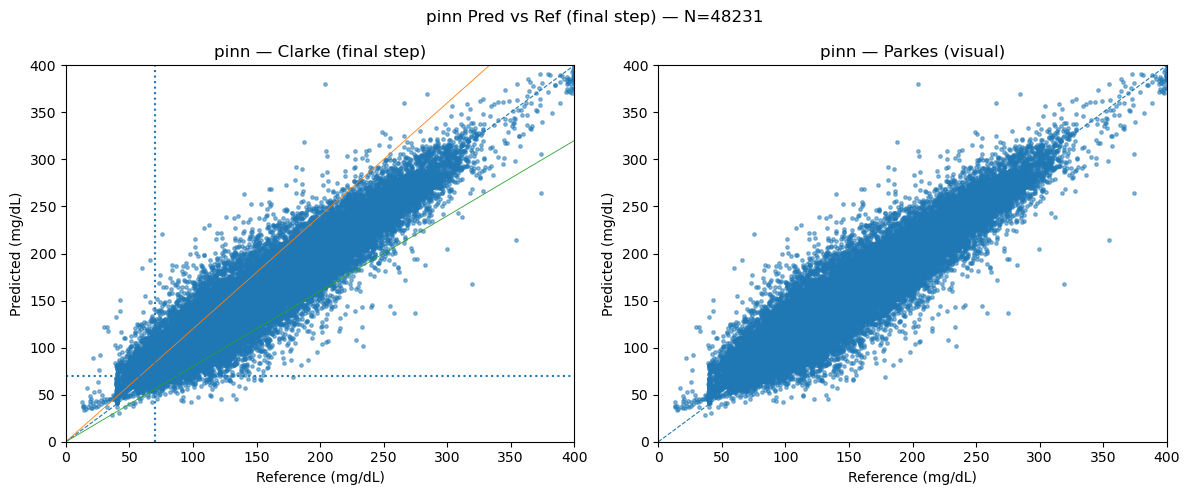


Glycemia detection — pinn (final step):


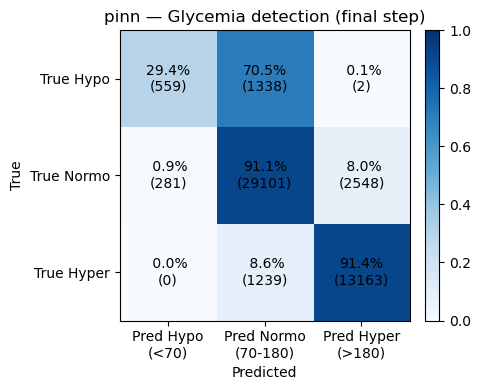

124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


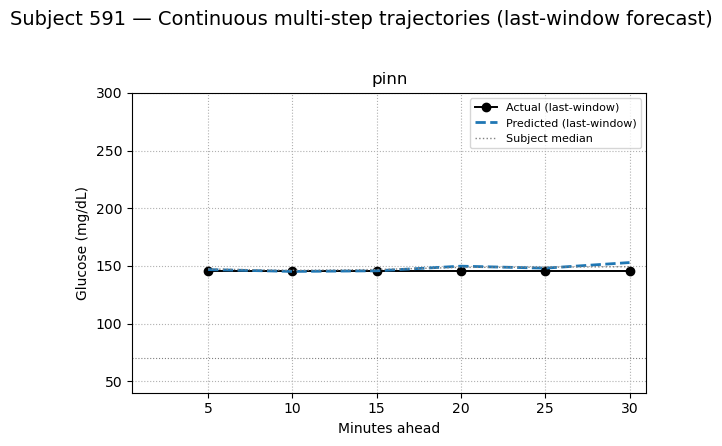

126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


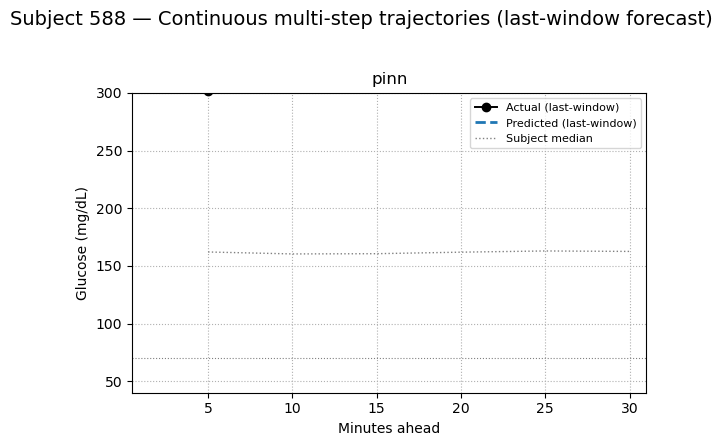

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


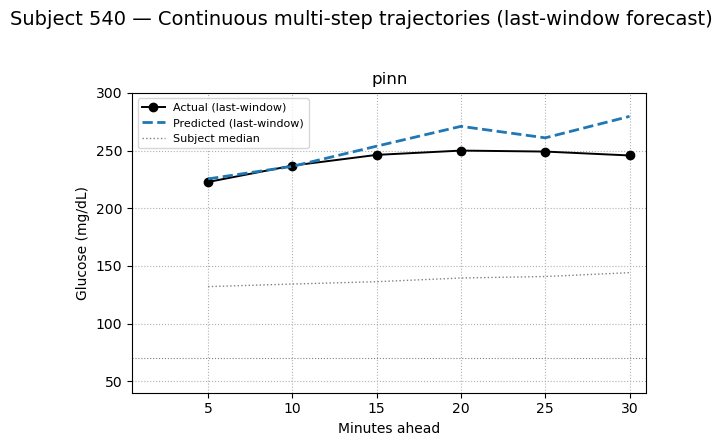

124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


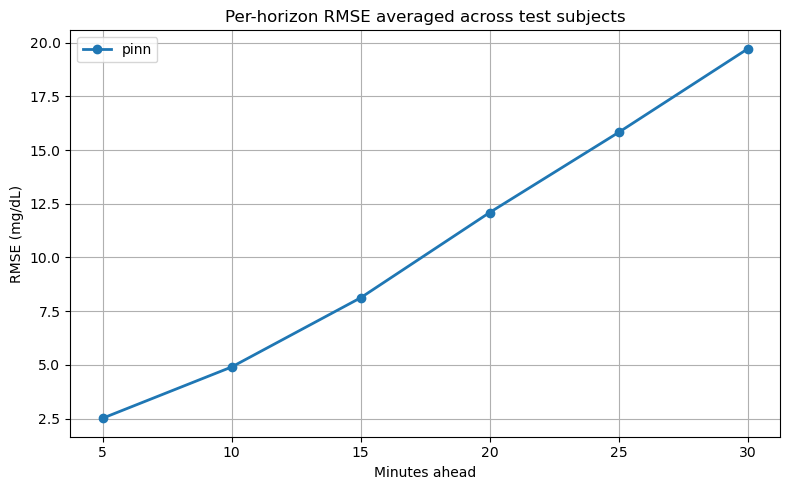


Done. Notes:
- Evaluation ran only for the PINN model.
- If you want SHAP-style explanations, use the separate SHAP cell that wraps the model to output a 2-D vector (e.g., flattened N_OUT glucose or final-step glucose).


In [6]:
# ============================
# CELL 3 — EVALUATION (PINN ONLY, shape-safe)
# ============================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from collections import Counter
import math
from scipy.signal import correlate

# --------------------------
# Helpers (scaler inversion, glycemia classes, metrics)
# --------------------------
def inv_cgm_with_cg_scaler(y_scaled):
    """y_scaled: array shape (..., N_OUT) or (..., N_OUT, 1) -> returns same shape in mg/dL"""
    if y_scaled is None or np.asarray(y_scaled).size == 0:
        return np.array([]).reshape(0, N_OUT)
    arr = np.asarray(y_scaled)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr.reshape(arr.shape[0], arr.shape[1])
    flat = arr.reshape(-1, 1)
    inv = cg_scaler.inverse_transform(flat).reshape(-1, N_OUT)
    return inv

HYPO = 70.0; HYPER = 180.0
def glycemia_class(x):
    x = np.asarray(x).reshape(-1)
    cls = np.full(x.shape, -1, dtype=int)
    cls[x < HYPO] = 0
    cls[(x >= HYPO) & (x <= HYPER)] = 1
    cls[x > HYPER] = 2
    return cls

# ---------- Updated Temporal Gain (TG) implementation ----------
def temporal_gain(y_true, y_pred, prediction_horizon):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if 'N_OUT' in globals():
        horizon = int(N_OUT)
    else:
        horizon = int(prediction_horizon // 5) or 1
    dt_minutes = float(prediction_horizon) / float(horizon)

    if y_true.ndim == 1 and y_pred.ndim == 1 and (y_true.size % horizon == 0) and (y_pred.size % horizon == 0):
        try:
            y_true = y_true.reshape(-1, horizon)
            y_pred = y_pred.reshape(-1, horizon)
        except Exception:
            return int(prediction_horizon)

    if y_true.ndim != 2 or y_pred.ndim != 2 or y_true.shape[1] != y_pred.shape[1]:
        return int(prediction_horizon)

    n_windows, L = y_true.shape
    max_lag_steps = int(prediction_horizon // dt_minutes)
    max_lag_steps = min(max_lag_steps, L - 1)

    tg_windows = []
    for i in range(n_windows):
        t = y_true[i].astype(float)
        p = y_pred[i].astype(float)
        if np.all(np.isnan(t)) or np.all(np.isnan(p)):
            tg_windows.append(0); continue
        if np.nanstd(t) < 1e-8 or np.nanstd(p) < 1e-8:
            tg_windows.append(0); continue
        t0 = t - np.nanmean(t)
        p0 = p - np.nanmean(p)
        cc = correlate(t0, p0, mode='full')
        full_lags = np.arange(-L + 1, L)
        valid_mask = (full_lags >= 0) & (full_lags <= max_lag_steps)
        valid_lags = full_lags[valid_mask]
        valid_cc   = cc[valid_mask]
        if valid_cc.size == 0:
            tg_windows.append(0); continue
        idx = np.argmax(np.abs(valid_cc))
        delay_steps = int(valid_lags[idx])
        delay_minutes = delay_steps * dt_minutes
        tg_val = prediction_horizon - delay_minutes
        tg_val = max(0.0, min(float(prediction_horizon), float(tg_val)))
        tg_windows.append(tg_val)

    if len(tg_windows) == 0:
        return int(prediction_horizon)
    tg_median = float(np.median(tg_windows))
    return int(round(tg_median))

# --- other metrics unchanged ---
def g_mean(y_true, y_pred):
    from sklearn.metrics import recall_score
    t = glycemia_class(y_true); p = glycemia_class(y_pred)
    recalls = recall_score(t, p, average=None, zero_division=0)
    recalls = np.where(recalls == 0, 1e-10, recalls)
    return float(np.exp(np.mean(np.log(recalls))))

def glucose_weighted_rmse(y_true, y_pred):
    y_true = np.asarray(y_true).flatten(); y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    w = np.maximum(y_true, 0.0)
    if w.sum() == 0:
        w = np.ones_like(w)
    w = w / w.sum()
    return math.sqrt(np.sum(w * (y_true - y_pred)**2))

def glucose_weighted_mae(y_true, y_pred):
    y_true = np.asarray(y_true).flatten(); y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    w = np.maximum(y_true, 0.0)
    if w.sum() == 0:
        w = np.ones_like(w)
    w = w / w.sum()
    return np.sum(w * np.abs(y_true - y_pred))

# Clarke/Parkes fallback (fast)
def clarke_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred): return None
    if (ref >= 70 and abs(pred - ref) <= 0.2 * ref) or (ref < 70 and abs(pred - ref) <= 20): return 'A'
    if (pred >= 330 and ref <= 50) or (pred <= 50 and ref >= 330): return 'E'
    if ref < 70 and pred >= 180: return 'C'
    if ref >= 180 and pred < 70: return 'D'
    return 'B'
def parkes_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred): return None
    err = pred - ref; rel_err = abs(err) / max(ref,1.0)
    if (ref < 70 and abs(err) <= 15) or (ref >= 70 and rel_err <= 0.2): return 'A'
    if rel_err <= 0.35: return 'B'
    if (ref < 70 and pred > 180) or (ref > 180 and pred < 70): return 'D'
    if rel_err > 0.6: return 'E'
    return 'C'

# --------------------------
# Models dict — ONLY the PINN predict function (shape-safe)
# --------------------------
models = {
    'pinn': pinn_model['predict']
}

# --------------------------
# Build arrays across ALL test windows for the pinn model (batched per subject)
# --------------------------
all_results = {}
for mname, mpredict in models.items():
    Ys = []
    for sid, info in per_subject_test.items():
        X_test = info['X']
        if X_test.shape[0] == 0:
            continue
        # IMPORTANT: mpredict should be a callable that returns scaled CGM as (n_windows, N_OUT, 1)
        yhat_scaled = mpredict(sid)
        yhat_scaled = np.asarray(yhat_scaled)
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        # convert to mg/dL
        yhat_mg = inv_cgm_with_cg_scaler(yhat_scaled)
        Ys.append(yhat_mg)
    all_results[mname] = np.vstack(Ys) if len(Ys) else np.zeros((0, N_OUT))

# Build ground-truth (all windows)
y_true_all_windows = []
for sid, info in per_subject_test.items():
    y_test = info['y']
    if y_test.shape[0] == 0:
        continue
    y_test_mg = inv_cgm_with_cg_scaler(y_test.reshape(-1, N_OUT))
    y_true_all_windows.append(y_test_mg)
if len(y_true_all_windows) == 0:
    raise RuntimeError("No test windows found.")
y_true_all = np.vstack(y_true_all_windows)

# --------------------------
# Metrics (per-horizon and final-step)
# --------------------------
horiz_steps = np.arange(1, N_OUT+1) * 5
print("\n=== Per-horizon RMSE / MAE for PINN ===")
per_horizon = {}
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        print(f"Model {mname}: no predictions")
        continue
    rmse_h = []
    mae_h = []
    for h in range(N_OUT):
        y_t = y_true_all[:, h]
        y_p = ypred_all[:, h]
        rmse_h.append(np.sqrt(mean_squared_error(y_t, y_p)))
        mae_h.append(mean_absolute_error(y_t, y_p))
    per_horizon[mname] = {'rmse': rmse_h, 'mae': mae_h}
    print(f"\nModel: {mname}")
    print("Horizon (min):", list(horiz_steps))
    print("RMSE (mg/dL): ", [round(v,2) for v in rmse_h])
    print("MAE  (mg/dL): ", [round(v,2) for v in mae_h])

print("\n=== Final-step aggregated metrics (30 min) ===")
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    ref = y_true_all[:, -1]; pred = ypred_all[:, -1]
    rmse_val = np.sqrt(mean_squared_error(ref, pred))
    mae_val  = mean_absolute_error(ref, pred)
    gw_rmse = glucose_weighted_rmse(ref, pred)
    gw_mae  = glucose_weighted_mae(ref, pred)
    tg = temporal_gain(y_true_all, ypred_all, prediction_horizon=5*N_OUT)
    gm = g_mean(ref, pred)
    print(f"\nModel: {mname}")
    print(f"  windows: {len(ref)}")
    print(f"  RMSE: {rmse_val:.3f}  MAE: {mae_val:.3f}")
    print(f"  Glucose-weighted RMSE: {gw_rmse:.3f}  Glucose-weighted MAE: {gw_mae:.3f}")
    print(f"  Temporal gain (min): {tg}   G-Mean: {gm:.4f}")

# --------------------------
# Clarke & Parkes (fallback) + scatter plots (final step)
# --------------------------
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    ref = y_true_all[:, -1]; pred = ypred_all[:, -1]
    cz = [clarke_zone_for_point(r,p) for r,p in zip(ref, pred)]
    pz = [parkes_zone_for_point(r,p) for r,p in zip(ref, pred)]
    c_counts = dict(Counter(cz)); p_counts = dict(Counter(pz)); total = len(ref)
    print(f"\n{mname} Clarke zones: ", {k:(c_counts[k], round(100*c_counts[k]/total,2)) for k in c_counts})
    print(f"{mname} Parkes zones : ", {k:(p_counts[k], round(100*p_counts[k]/total,2)) for k in p_counts})

    fig, ax = plt.subplots(1,2, figsize=(12,5))
    ax0 = ax[0]
    ax0.scatter(ref, pred, s=6, alpha=0.5)
    ax0.plot([0,400],[0,400],'--', linewidth=0.8)
    xs = np.linspace(0,400,100); ax0.plot(xs, 1.2*xs, linewidth=0.6); ax0.plot(xs, 0.8*xs, linewidth=0.6)
    ax0.axvline(70, linestyle=':'); ax0.axhline(70, linestyle=':')
    ax0.set_xlim(0,400); ax0.set_ylim(0,400)
    ax0.set_xlabel('Reference (mg/dL)'); ax0.set_ylabel('Predicted (mg/dL)')
    ax0.set_title(f"{mname} — Clarke (final step)")

    ax1 = ax[1]
    ax1.scatter(ref, pred, s=6, alpha=0.5)
    ax1.plot([0,400],[0,400],'--', linewidth=0.8)
    ax1.set_xlim(0,400); ax1.set_ylim(0,400)
    ax1.set_xlabel('Reference (mg/dL)'); ax1.set_ylabel('Predicted (mg/dL)')
    ax1.set_title(f"{mname} — Parkes (visual)")
    plt.suptitle(f"{mname} Pred vs Ref (final step) — N={total}")
    plt.tight_layout()
    plt.show()

# --------------------------
# Glycemia detection confusion matrices for each model (final step)
# --------------------------
def compute_glycemia_confusion(y_true, y_pred):
    y_t = np.asarray(y_true).reshape(-1); y_p = np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_t) & np.isfinite(y_p)
    y_t = y_t[mask]; y_p = y_p[mask]
    counts = np.zeros((3,3), dtype=int)
    if y_t.size == 0:
        return counts, np.full_like(counts, np.nan, dtype=float)
    tcls = glycemia_class(y_t); pcls = glycemia_class(y_p)
    for t,p in zip(tcls, pcls):
        if 0<=t<=2 and 0<=p<=2:
            counts[t,p] += 1
    pct = np.full_like(counts, np.nan, dtype=float)
    for i in range(3):
        s = counts[i].sum()
        if s>0:
            pct[i,:] = counts[i,:] / float(s)
    return counts, pct

def plot_confusion_heatmaps(counts, pct, title=""):
    fig, ax = plt.subplots(1,1, figsize=(5,4))
    im = ax.imshow(pct, vmin=0.0, vmax=1.0, cmap='Blues', interpolation='nearest')
    ax.set_xticks(np.arange(3)); ax.set_yticks(np.arange(3))
    labels = ['Pred Hypo\n(<70)','Pred Normo\n(70-180)','Pred Hyper\n(>180)']
    ax.set_xticklabels(labels); ax.set_yticklabels(['True Hypo','True Normo','True Hyper'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            c = counts[i,j]; p = pct[i,j]
            if np.isnan(p):
                txt = "n/a\n(0)"
            else:
                txt = f"{p*100:4.1f}%\n({c})"
            ax.text(j, i, txt, ha='center', va='center', color='black', fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

for mname, ypred_all in all_results.items():
    if ypred_all.size == 0: continue
    counts, pct = compute_glycemia_confusion(y_true_all[:, -1], ypred_all[:, -1])
    print(f"\nGlycemia detection — {mname} (final step):")
    plot_confusion_heatmaps(counts, pct, title=f"{mname} — Glycemia detection (final step)")

# --------------------------
# Simple continuous multi-step trajectories plotting (last-window forecast)
# --------------------------
model_order = ['pinn']
n_models = len(model_order)
selected_sids = list(per_subject_test.keys())[:3]
t_h = np.arange(1, N_OUT+1) * 5

if len(selected_sids) == 0:
    print("No test subjects available for plotting.")
else:
    for sid in selected_sids:
        info = per_subject_test[sid]
        X_test = info['X']
        y_test = info['y']
        if X_test.shape[0] == 0:
            continue
        last_idx = -1
        y_test_arr = np.asarray(y_test)
        if y_test_arr.ndim == 3 and y_test_arr.shape[-1] == 1:
            y_test_flat_scaled = y_test_arr.reshape(y_test_arr.shape[0], y_test_arr.shape[1])
        else:
            y_test_flat_scaled = y_test_arr
        y_test_mg = inv_cgm_with_cg_scaler(y_test_flat_scaled)
        actual_traj = y_test_mg[last_idx]

        fig, axs = plt.subplots(1, n_models, figsize=(6*n_models, 4.5), sharey=True)
        if n_models == 1:
            axs = [axs]
        fig.suptitle(f"Subject {sid} — Continuous multi-step trajectories (last-window forecast)", fontsize=14)

        for i_m, mname in enumerate(model_order):
            ax = axs[i_m]
            yhat_scaled_all = models[mname](sid)
            yhat_scaled_all = np.asarray(yhat_scaled_all)
            if yhat_scaled_all.size == 0:
                ax.text(0.5, 0.5, "no preds", ha='center', va='center')
                ax.set_title(mname); continue
            if yhat_scaled_all.ndim == 3 and yhat_scaled_all.shape[-1] == 1:
                yhat_scaled_all = yhat_scaled_all.reshape(yhat_scaled_all.shape[0], yhat_scaled_all.shape[1])
            yhat_mg_all = inv_cgm_with_cg_scaler(yhat_scaled_all)
            pred_traj = yhat_mg_all[last_idx]

            ax.plot(t_h, actual_traj, '-o', color='black', markersize=6, linewidth=1.4, label='Actual (last-window)')
            ax.plot(t_h, pred_traj, '--', color='tab:blue', linewidth=2.0, label='Predicted (last-window)')
            med = np.nanmedian(yhat_mg_all, axis=0)
            ax.plot(t_h, med, ':', color='gray', linewidth=1.0, label='Subject median')

            ax.set_title(mname)
            ax.set_xlabel('Minutes ahead')
            if i_m == 0:
                ax.set_ylabel('Glucose (mg/dL)')
            ax.set_xticks(t_h)
            ax.set_xlim(0.5, t_h[-1] + 1)
            ax.axhline(HYPO, color='gray', linestyle=':', linewidth=0.8)
            ax.set_ylim(40, 300)
            ax.grid(True, linestyle=':')
            ax.legend(fontsize=8)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

# Combined summary plot: per-horizon RMSE averaged across subjects
model_names = list(all_results.keys())
per_subject_rmse = {m: [] for m in model_names}
for sid, info in per_subject_test.items():
    y_test = info['y']
    if y_test.shape[0] == 0:
        continue
    y_true_mg = inv_cgm_with_cg_scaler(y_test.reshape(-1, N_OUT))
    for m in model_names:
        yhat_scaled = models[m](sid)
        if np.asarray(yhat_scaled).size == 0:
            continue
        yhat_scaled = np.asarray(yhat_scaled)
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        yhat_mg = inv_cgm_with_cg_scaler(yhat_scaled)
        rmse_per_h = [np.sqrt(mean_squared_error(y_true_mg[:,h], yhat_mg[:,h])) for h in range(N_OUT)]
        per_subject_rmse[m].append(rmse_per_h)

plt.figure(figsize=(8,5))
for m in model_names:
    subj_rmses = np.array(per_subject_rmse[m]) if len(per_subject_rmse[m])>0 else np.zeros((0, N_OUT))
    if subj_rmses.size == 0:
        continue
    mean_rmse = np.nanmean(subj_rmses, axis=0)
    plt.plot(t_h, mean_rmse, '-o', label=m, linewidth=2)
plt.xticks(t_h)
plt.xlabel('Minutes ahead'); plt.ylabel('RMSE (mg/dL)')
plt.title('Per-horizon RMSE averaged across test subjects')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print("\nDone. Notes:")
print("- Evaluation ran only for the PINN model.")
print("- If you want SHAP-style explanations, use the separate SHAP cell that wraps the model to output a 2-D vector (e.g., flattened N_OUT glucose or final-step glucose).")


In [5]:
# ===========================================
# SHAP FEATURE IMPORTANCE FOR PINN MODEL
# ===========================================

import shap
import numpy as np

# Use a small subset to keep SHAP efficient
X_sample = X_tr_all[:500]

# SHAP deep explainer requires a function returning predictions
explainer = shap.DeepExplainer(PINN_model, X_sample)

# Compute SHAP on a test batch
X_test_sample = list(per_subject_test.values())[0]['X'][:200]
shap_vals = explainer.shap_values(X_test_sample)

# shap_values is list per output unit → we take G predictions only
shap_G = shap_vals[0]  # shape: (samples, N_IN, features)

# Aggregate importance across time steps
importance = np.mean(np.abs(shap_G), axis=(0,1))

# Plot
plt.figure(figsize=(10,5))
plt.bar(range(len(importance)), importance)
plt.title("PINN Feature Importance (SHAP)")
plt.xlabel("Feature index")
plt.ylabel("Mean |SHAP value|")
plt.grid(True)
plt.show()

print("Top features by importance:")
for idx in np.argsort(importance)[::-1][:10]:
    print(f"Feature {idx}: importance={importance[idx]:.4f}")


AssertionError: The model output must be a vector or a single value!